In [15]:
#importing important libraries
import numpy as np
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [16]:
#loading dataset
df = pd.read_csv('../../cleaned_data/titanic_cleaned.csv')



In [17]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


FEATURE ENGINEERING

In [18]:
df_fe = df.copy()

#Feature_1 Family Size
df_fe['Family_Size'] = df_fe['Parch'] + df_fe['SibSp'] + 1

#herer i added columns parch and sibsp for counting Family_Size



In [19]:
#Feature_2 is_alone
df_fe['is_alone'] = (df_fe['Family_Size'] == 1).astype(int)

In [20]:
#Feature_3 Age_x_Pclass 
df_fe['Age_x_Pclass'] = df_fe['Age'] * df_fe['Pclass']

#multiplying age * Pclass to get age by pclass

In [21]:
#Feature_4 Fare per Person

df_fe['FarePerPerson'] = df_fe['Fare'] / df_fe['Family_Size']
#dividing fare/family_size to get fare by each person


In [22]:
# Feature_5 Age Group
df_fe['AgeGroup'] = pd.cut(
    df_fe['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[0, 1, 2, 3, 4]  # child, teen, young adult, adult, senior
).astype(int)


print('new features created!')
print('New columns:', ['Family_Size', 'is_alone', 'Age_x_Pclass', 'FarePerPerson', 'AgeGroup'])
df.head()

new features created!
New columns: ['Family_Size', 'is_alone', 'Age_x_Pclass', 'FarePerPerson', 'AgeGroup']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


In [23]:
df = df_fe 

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Size,is_alone,Age_x_Pclass,FarePerPerson,AgeGroup
0,0,3,1,22.0,1,0,7.2500,0,2,0,66.0,3.62500,2
1,1,1,0,38.0,1,0,71.2833,1,2,0,38.0,35.64165,3
2,1,3,0,26.0,0,0,7.9250,0,1,1,78.0,7.92500,2
3,1,1,0,35.0,1,0,53.1000,0,2,0,35.0,26.55000,2
4,0,3,1,35.0,0,0,8.0500,0,1,1,105.0,8.05000,2


VISUALIZING NEW FEATURES

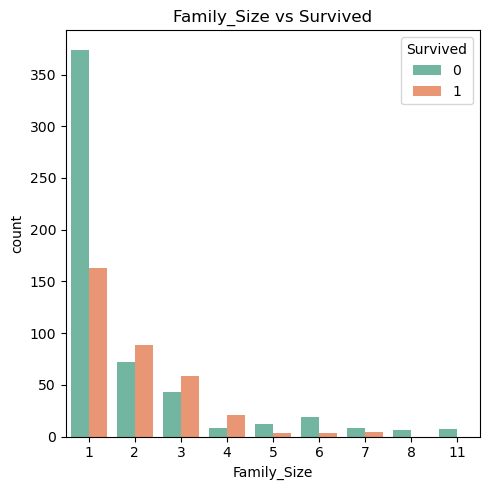

In [24]:
#Family_Size vs Survival

plt.figure(figsize=(5,5))

sns.countplot(x='Family_Size', hue='Survived', data=df, palette='Set2')

plt.title('Family_Size vs Survived')

plt.tight_layout()
plt.show()

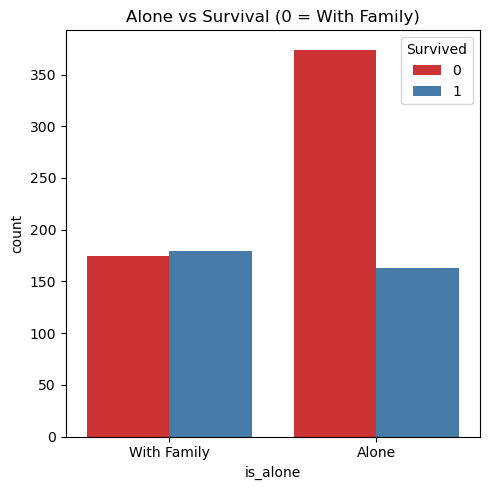

In [25]:
# Is Alone vs Survival
 
plt.figure(figsize=(5,5))

sns.countplot(x='is_alone', hue='Survived', data=df, palette='Set1')

plt.title('Alone vs Survival (0 = With Family)')
plt.xticks([0,1], ['With Family', 'Alone'], rotation=0)

plt.tight_layout()
plt.show()

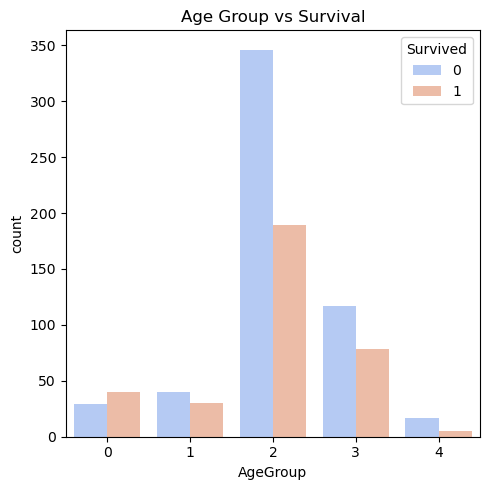

In [26]:
# age_group vs survival

plt.figure(figsize=(5,5))

sns.countplot(x='AgeGroup', hue='Survived', data=df, palette='coolwarm')

plt.title('Age Group vs Survival')

plt.tight_layout()
plt.show()

SAVING FEATURED DATASET

In [27]:
#So, simply put, first of all, I loaded the cleaned data set from `cleaned_data/titanic_cleaned.csv`. 
#After that, during the feature engineering stage, new features were engineered, and missing values, 
#if any, were handled. Following this, the final data was exported in a file named `titanic_featured.csv`.
#Finally, using this data, I trained two models Logistic Regression and Random Forest.
os.makedirs('../../cleaned_data', exist_ok=True)
df.to_csv('../../cleaned_data/titanic_featured.csv', index=False)
print('saved to cleaned_data/titanic_featured.csv')
print(f'shape: {df.shape}')
print(f'columns: {list(df.columns)}')


saved to cleaned_data/titanic_featured.csv
shape: (891, 13)
columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Family_Size', 'is_alone', 'Age_x_Pclass', 'FarePerPerson', 'AgeGroup']
